# **딥러닝 모델 템플릿**

<br>

### **TIPS 데이터 활용하여 쉽게 모델링하기**
- 간단하게 쉽게 딥러닝 모델링 만들어 보기
- 원하는 컬럼을 선택해서 회귀 모델, 분류 모델 만들어 보기
- 잘 몰라도 아래 순서에 맞게 , 이런식으로 실행하면 되겠구나 느끼기
- 여러분이 처음 한다고 생각하고 템플릿 작성함
- 백문이불여일타!! 반복 연습이 중요하다.

### **모델링 프로세스**
1. 데이터 가져오기
2. 데이터 분석
3. X , y 나누기
4. 딥러닝 모델링

<br>

## **0. tips2.csv 데이터 만들기**

In [1]:
# !pip install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

tips = sns.load_dataset('tips')

# tips.sex.replace(['Female', 'Male'], [0,1], inplace=True)
# tips.smoker.replace(['No', 'Yes'], [0,1], inplace=True)
# tips.time.replace(['Dinner', 'Lunch'], [1,0], inplace=True)
# 강의에서는 v2.0 이하라서 위 코드 동작
# 나는 pandas 버전은 v3.0.2로 v2.0 이상이라서 위 코드 동작 불가 (Categorical dtype 에러 발생)
# https://pandas.pydata.org/docs/user_guide/categorical.html 참고
tips['sex']    = tips['sex'].map({'Female': 0, 'Male': 1})
tips['smoker'] = tips['smoker'].map({'No': 0, 'Yes': 1})
tips['time']   = tips['time'].map({'Dinner': 1, 'Lunch': 0})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
tips.day = le.fit_transform(tips.day)

tips.to_csv('tips2.csv', index=False)

<br>
<br>
<br>

---

## **1. 데이터 가져오기**
- 먼저, 데이터가 있어야 모델링을 만들수 있다.
- 데이터 가져오는 방법에는 여러가지 있다.
 - 본인 데이터를 직접 올리는 방법
 - 기존에 제공하는 데이터 가져다 쓰는 방법
- 반드시 데이터를 읽어와야 후속 작업을 할수 있다.

In [2]:
# 필요한 라이브러리 가져오기
# 그냥 무조건 가져온다고 생각하자 : pandas, numpy, seaborn, matplotlib.pyplot
# seaborn 설치가 되어 있지 않으면 라이브러리는 설치 필요 : !pip install seaborn
# !pip install seaborn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#  판다스의 read_csv 함수를 찾았는데, 사용법을 모른다면
# 1. 아래와 같이 help 찾는다. ? , shift+Tab 2가지 방법으로 쥬피터 노트북에서 help을 볼수 있다.
# 2. 구글링 : pandas read_csv --> 판다스 사이트 접속해서 도움말 보기 : https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

pd.read_csv?

### TIPS 데이터셋 가져오기

In [3]:
# tips2.csv 파일 읽고  tips2 데이터프레임에 저장합니다.

tips2 = pd.read_csv('tips2.csv')

In [4]:
# head() 함수를 통해서 tips2 데이터프레임의 앞 5개 데이터를 확인 할수 있으며
# 인덱스와 컬럼들과 value값들로 구성됩니다.

tips2.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,1,2
1,10.34,1.66,1,0,2,1,3
2,21.01,3.50,1,0,2,1,3
3,23.68,3.31,1,0,2,1,2
4,24.59,3.61,0,0,2,1,4


![tips](https://github.com/gzone1357/Image1/raw/main/git1.png)

---

## **2. 데이터 분석**
- 데이터 값이 어떻게 되어 있으며, 어떤 흐름을 보이는지, 다른 컬럼과의 관계는 어떤지를 파악하는 거다.
- 눈으로 데이터 수치를 보고 어떤 흐름인지 파악할수 있지만,
- 시각화를 통한다면 쉽게 흐름을 파악할수 있으니, 할수 있으면 사용해라.
- 여러분에게는 어려울수 있으니, 아, 이렇게 데이터를 가지고 시각화를 할수 있구나 느낀면 된다.


### **<font color=blue>하지만, 우리는 여기서는 데이터 분석을 하지 않아요.</font>**
### **<font color=red>데이터가 이미 정제되어 있어 머신러닝과 딥러닝 모델링에 집중하도록 할게요!!</font>**

<br>
<br>
<br>

---

## **3. [회귀모델 ] X, y 나누기**
- 지도학습 경우 데이터와 정답이 있어야 합니다.
- 데이터에 해당하는 X와 정답에 해당하는 y가 있어야 합니다.
- 아래와 같이 판다스를 이용하면 X, y를 쉽게 나눌수 있어요.
- X, y 데이터를 가지고 모델 학습하고 검증할수 있는 학습 데이터셋과 테스트 데이터셋으로 나눠 사용합니다.
- 그리고 레이블(y) 값을 보고 회귀 모델인지, 분류 모델인지 구별할수 있어요.
  - 레이블(y) : 학점 A/B/C/DF , 남녀 남/여, 숫자 0~9 --> 범주형으로 되어 있으면 분류 모델
  - 레이블(y) : 삼성전자 주가, 습도/온도, 유가동향 등 --> 연속형으로 되어 있으면 회귀 모델

### **<font color=blue>우리는 회귀 모델을 만들어야 하는데, 어떤 컬럼을 정답(레이블, y)를 정할까요?</font>**
### **<font color=blue>회귀모델 위해서 연속형 컬럼을 레이블(y)로 선택해야 합니다.</font>**

In [5]:
# tips2 데이터프레임의 뒤 5개 행 라인 보기
# 연속적인 값들이 있는 컬럼은 무엇이 있나요?

tips2.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,1,0,1,1,3
240,27.18,2.00,0,1,1,1,2
241,22.67,2.00,1,1,1,1,2
242,17.82,1.75,1,0,1,1,2
243,18.78,3.00,0,0,3,1,2


### **<font color=blue>연속적인 값을 나타내는 컬럼이 total_bill, tip 컬럼들이 있네요</font>**

In [6]:
# 다시 한번 tips2 내용을 보겠습니다.

tips2.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,1,2
1,10.34,1.66,1,0,2,1,3
2,21.01,3.50,1,0,2,1,3


### **그중에서 정답(레이블, y)을 tip 컬럼으로 정했고, tip의 값들이 연속적인 값이니 <font color=blue>회귀 모델</font>이 되겠네요.**

In [7]:
# tips2 데이터프레임(테이블)에서 tip 컬럼만 제외하면 나머지가 X가 되겠네요.
# tips 컬럼을 제외하고 나머지 컬럼들을 일일히 리스트에 나열해 조회해 보겠습니다.

tips2[['total_bill', 'sex', 'smoker', 'day', 'time', 'size']]

,total_bill,sex,smoker,day,time,size
0,16.99,0,0,2,1,2
1,10.34,1,0,2,1,3
2,21.01,1,0,2,1,3
3,23.68,1,0,2,1,2
4,24.59,0,0,2,1,4
...,...,...,...,...,...,...
239,29.03,1,0,1,1,3
240,27.18,0,1,1,1,2
241,22.67,1,1,1,1,2
242,17.82,1,0,1,1,2


In [8]:
# 레이블(y)는 tips2 데이터프레임(테이블)에서 tip 컬럼만 가져오면 되겠네요.
# 출력 결과는 인덱스와 value값으로 이루어진 시리즈 형태입니다.

tips2['tip']

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

### **<font color=blue>판다스의 drop 함수를 이용하면 쉽게 X, y를 나눌수 있어요!!</font>**

In [ ]:
# ? 활용하여 도움말 보기

tips2.drop?

In [9]:
# X 데이터 분리 : 판다스 drop 함수 활용
# 입력 : 'tip', axis=1

X = tips2.drop('tip', axis=1)

In [10]:
# 분리된 X 데이터 확인 : 데이터 타입이 데이터프레임 확인
# 레이블 tip 컬럼은 보이지 않음을 확인할수 있습니다.

X

,total_bill,sex,smoker,day,time,size
0,16.99,0,0,2,1,2
1,10.34,1,0,2,1,3
2,21.01,1,0,2,1,3
3,23.68,1,0,2,1,2
4,24.59,0,0,2,1,4
...,...,...,...,...,...,...
239,29.03,1,0,1,1,3
240,27.18,0,1,1,1,2
241,22.67,1,1,1,1,2
242,17.82,1,0,1,1,2


In [11]:
# y 데이터 분리 : 'tip' 컬럼값만 분리해서 가져오면 됨.

y = tips2['tip']

In [12]:
# 분리된 y 데이터 확인 : 데이터 타입이 Series 확인
# y 값이 실수형으로 되어 있음 확인

y

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

### **X, y 데이터를 가지고 학습 데이터셋과 테스트 데이터셋 만들어 볼게요.**

In [13]:
# X, y 데이터를 가지고 학습 데이터셋과 테스트 데이터셋 만들어 주는 train_test_split 함수가 있습니다.
# train_test_split 함수를 이용하면 쉽게 학습 데이터셋과 테스트 데이터셋 만들수 있습니다.
# 사이킷런의 train_test_split 함수 불러 옵니다.

from sklearn.model_selection import train_test_split

In [ ]:
# ? 활용하여 도움말 보기
train_test_split?

In [14]:
# train_test_split 함수
# 1. X ,y 입력
# 2. test_size=0.2 --> train set : test set  = 8 : 2
# 3. random_state 사용하지 않으면 실행할때마다 학습셋과 테스트셋이 다르게 나와 고정하기 위해 사용
# 4. train_test_split 함수 결과로 X_train, X_test, y_train, y_test 나옴.

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [15]:
# 학습 데이터셋과 테스트 데이터셋의 사이즈 확인

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 6), (49, 6), (195,), (49,))

In [16]:
# 뒤쪽에서 사용하게 편하게 데이터프레임을 넘파이(numpy)로 변경합니다.

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

<br>
<br>
<br>

---

<br>
<br>
<br>

![DNN](https://github.com/gzone1357/Image1/raw/main/DNN%EA%B5%AC%ED%98%84.png)

#### **먼저, 회귀 혹은 분류  결정**
+ 회귀 :
  - 삼성전자 주가 예측  >  아웃풋 동그라미 1개 , activation=None (혹은 linear)
  -  Loss 함수 : mse , mae
+ 분류 :
  - 남자,여자 예측 > 아웃풋 동그라미  1개 , activation=‘sigmoid’
  - 남자,여자 예측 >  아웃풋 동그라미  2개 이상 , activation=‘softmax’
  - 학점 A,B,C,D,F 예측 : 아웃풋 동그라미 5개 , activation=‘softmax’
  - Loss 함수 : 아웃풋 동그라미 1개 : binary_crossentropy
  - Loss 함수 : 아웃풋 동그라미 2개 이상 : sparse_categorical_crossentropy

---

## **4. (회귀) 딥러닝 모델링**

![DNN](https://github.com/gzone1357/Image1/raw/main/Deep-learning-8-i2tutorials.jpg)

### **1) 딥러닝 모델링 하기 위해, 제일 먼저 필요한 라이브러리 불러오기 입니다.**

In [17]:
# 딥러닝 필요한 라이브러리 가져오기
# Sequential : 위의 전체 그림 레이아웃이라고 보시면 됩니다.
# Dense : 히든 레이어, 아웃풋 레이어을 가르키는 층으로 보시면 됩니다.
# EarlyStopping : callback으로 매 학습마다 성능을 측정하고 성능이 더 이상 나아지지 않으면 조기종료
# ModelCheckpoint : 주로 성능이 제일 좋을때 모델을 저장하는데 사용

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### **2) 전체 그림을 그릴수 있는 도화지 Sequential 정의합니다.**

In [18]:
# 전체 그림을 그릴수 있는 도화지가 필요하듯이,
# 딥러닝 모델을 만들기 위한 Sequential 함수를 정의하여 model 이름으로 저장합니다.

model = Sequential()

### **3) 도화지를 채우기전에 입력과 출력을 고려해 봅시다.**

In [19]:
# 입력 레이어에서 받아들여야 할 입력 갯수는 얼마일까요? X의 컬럼의 갯수만큼이 입력으로 들어가겠죠.
# 출력 레이어에서 출력으로 나가야할 갯수는 얼마일까요? 회귀모델이며, tip(y) 값이 예측하면 되겠죠.
# X_train.shape, y_train.shape 출력해 보자

print(X_train.shape)
print(y_train.shape)

(195, 6)
(195,)


### **4) 도화지에 우리가 필요한만큼의 레이어를 만들수 있으며 먼저 1개의 레이어 만들어 봅시다.**

In [20]:
# 첫번째 레이어 즉, 첫번째 히든레이어(Dense Layer)가 되겠네요.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 히든레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 4개 동그라미 그립시다. (동그라미 갯수는 마음대로 해도 됩니다.)
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 없는 경우도 있지만, 대부분 'relu' 사용하면 됩니다.
# 첫번째 히든 레이어는 입력을 꼭, 받아야 합니다. 몇개의 입력을 받을지 모델에게 알려 주어야 합니다.

model.add(  Dense( 4, activation='relu', input_shape=(6,)  )  )

2026-04-20 20:01:49.050596: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-20 20:01:49.050820: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-20 20:01:49.050829: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-04-20 20:01:49.051069: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-20 20:01:49.051091: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### **5) 도화지에 1개의 레이어를 추가해 볼게요.**

In [21]:
# 두번째 레이어 즉, 두번째 히든레이어(Dense Layer)가 되겠네요.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 히든레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 4개 동그라미 그립시다. (동그라미 갯수는 마음대로 해도 됩니다.)
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 없는 경우도 있지만, 대부분 'relu' 사용하면 됩니다.
# 두번째 히든 레이어부터는 입력을 몇개 받을지 모델에게 알려줄 필요가 없어요. 알아서 계산하기 때문입니다.

model.add(  Dense(  4, activation='relu',  )  )

### **6) 도화지에 출력 레이어를 추가해 봅시다.**

In [22]:
# 세번째 레이어 즉, 세번째 히든레이어(Dense Layer)로 마지막 레이어이기에 아웃풋 레이어 됩니다.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 아웃풋 레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 1개의 출력이므로 1개 동그라미 그립시다.
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 회귀 모델이기에 활성화 함수를 None (혹은 linear) 으로 지정합니다.

model.add(  Dense(  1, activation=None,  )  )

### **7) 도화지에서 그려진 전체 그림을 보겠습니다.**

In [23]:
# summary() 함수를 사용해서 전체 레이아웃을 봅니다.

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

### **8) 도화지에서 그려진 전체 그림을 한꺼번에 그려보면**

In [24]:
# Sequential 모델 만들기 --> model 변수 저장
# input layer : (6, )
# hidden layer : 4 unit , activation='relu'
# hidden layer : 4 unit , activation='relu'
# output layer : 1 unit , activation=None

model = Sequential()
model.add(  Dense( 4, activation='relu', input_shape=(6,)  )  )
model.add(  Dense( 4, activation='relu',  )  )
model.add(  Dense( 1, activation=None  )  )

### **9) 도화지에서 그려진 그림을 컴퓨터가 이해해서 성능 좋은 모델을 만들어 보겠습니다.**

In [25]:
# 모델 컴파일 : compile > 컴퓨터가 좋은 성능의 모델이 될수 있도록 여러가지 옵션을 설정해야 합니다.
# 회귀 모델 loss : mse, mae > 우리는 loss='mse' 사용하겠습니다.
# 최적화 알고리즘 : optimizer='adam'
# 모델의 성능 측정 : metrics=['mae']

model.compile(  loss='mse', optimizer='adam', metrics=['mae']  )

### **10) 도화지에 그려진 그림을 가지고 모델을 만들었으니, 학습을 진행하도록 할게요.**

In [26]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=10,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# 학습결과 저장 : history

history = model.fit(  X_train, y_train, epochs=10, batch_size=8  )

Epoch 1/10


2026-04-20 20:02:41.852019: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 72.3667 - mae: 7.9667
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 44.9663 - mae: 6.2248
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26.0557 - mae: 4.7251
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13.3600 - mae: 3.2973
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.2598 - mae: 2.1398
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5635 - mae: 1.5289
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5349 - mae: 1.2522
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.1148 - mae: 1.1290
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8342 - mae: 1.0338
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7207 - mae: 0.9974


### **11) X_train, y_train 학습 데이터셋으로 모델 학습하고 , X_test, y_test 테스트 데이터셋으로 학습  검증합니다.**
> epochs = 50 으로 수정

In [27]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=50,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# X_test, y_test 테스트 데이터셋으로 학습 잘되는지 검증 합니다. : validation_data=(X_test, y_test)
# 학습결과 저장 : history

history = model.fit(  X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test)  )

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 1.6585 - mae: 0.9751 - val_loss: 1.1177 - val_mae: 0.8389
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6355 - mae: 0.9666 - val_loss: 1.1358 - val_mae: 0.8392
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6238 - mae: 0.9617 - val_loss: 1.1561 - val_mae: 0.8403
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6203 - mae: 0.9601 - val_loss: 1.1663 - val_mae: 0.8401
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6166 - mae: 0.9582 - val_loss: 1.1785 - val_mae: 0.8400
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6148 - mae: 0.9570 - val_loss: 1.1823 - val_mae: 0.8393
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6134 - mae: 0.9563 - val_loss: 1.1869 - val_mae: 0.8390
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.6103 - mae: 0.9551 - val_loss: 1.1831 - val_mae: 0.8373
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.607

### **12) 모델 성능이 더 이상 좋아지지 않는데 50번씩 학습하고 있다. 조기종료와 성능 좋은 모델 저장하자.**

In [31]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=50,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# X_test, y_test 테스트 데이터셋으로 학습 잘되는지 검증 합니다. : validation_data=(X_test, y_test)
# 학습결과 저장 : history

# EarlyStopping : 매 epoch 마다 'val_loss' 측정해서  3번 동안 더 이상 성능이 나아지지 않으면 조기 종료
es = EarlyStopping( monitor='val_loss' , patience=3 , verbose=1 )

# ModelCheckpoint : 매 epoch 마다 'val_loss' 측정해서  이전보다 성능이 더 좋아지면 모델을 저장
mc = ModelCheckpoint( 'best_model.keras', monitor='val_loss', save_best_only=True, verbose=1  )

history = model.fit(  X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test) , callbacks=[es, mc] )

Epoch 1/50
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4874 - mae: 0.9198
Epoch 1: val_loss improved from None to 1.01244, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.5158 - mae: 0.9227 - val_loss: 1.0124 - val_mae: 0.7779
Epoch 2/50
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5185 - mae: 0.9389
Epoch 2: val_loss improved from 1.01244 to 1.00886, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5132 - mae: 0.9220 - val_loss: 1.0089 - val_mae: 0.7769
Epoch 3/50
22/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2532 - mae: 0.8270
Epoch 3: val_loss did not improve from 1.00886
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.5161 - mae: 0.9230 - val_loss: 1.0147 - val_mae: 0.7773
Epoch 4/50
20/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.3599 - mae: 0.8558
Epoch 4: val_loss improved from 1.00886 to 0.999

### **13) 학습된 딥러닝 모델을 가지고 tip 예측해 보도록 하겠습니다.**

In [32]:
# 테스트 데이터의 2개의 X, y 값 확인

X_test[0:2], y_test[0:2]

(array([[19.82,  1.  ,  0.  ,  1.  ,  1.  ,  2.  ],
        [ 8.77,  1.  ,  0.  ,  2.  ,  1.  ,  2.  ]]),
 array([3.18, 2.  ]))

In [33]:
# 0 라인 샘플 데이터을 모델 입력해서 예측하기
# rfr 모델의 predict 함수 활용
# 입력 : X_test[0:2], 결과 : pred 저장
# pred 결과 출력

pred = model.predict(X_test[0:2])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
[[2.1788769 ]
 [0.82372856]]


### **14) 학습시 loss, mse에 대해 그래프를 그려 보겠습니다.**

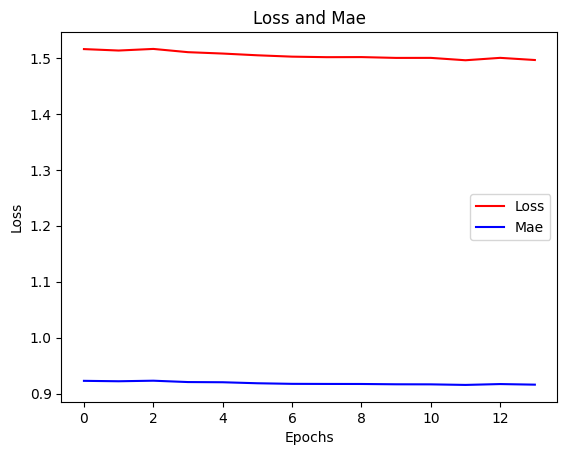

In [34]:
# matplotlib 이용하여 그래프 그리기
# 1. plot 그리기 : 입력  history.history['loss'], 'r'
# 2. plot 그리기 : 입력  history.history['mae'], 'b'
# 3. title : 'Loss and Mae'
# 4. xlabel : "Epochs"
# 5. ylabel : "Loss"
# 6. legend : ["Loss", "Mae"]
# 7. plt.show()


plt.plot(history.history['loss'], 'r')
plt.plot(history.history['mae'], 'b')
plt.title('Loss and Mae')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Loss", "Mae"])
plt.show()

<br>
<br>
<br>

---

## **5. [분류 모델] X, y 나누기**
- 지도학습 경우 데이터와 정답이 있어야 합니다.
- 데이터에 해당하는 X와 정답에 해당하는 y가 있어야 합니다.
- 아래와 같이 판다스를 이용하면 X, y를 쉽게 나눌수 있어요.
- X, y 데이터를 가지고 모델 학습하고 검증할수 있는 학습 데이터셋과 테스트 데이터셋으로 나눠 사용합니다.
- 그리고 레이블(y) 값을 보고 회귀 모델인지, 분류 모델인지 구별할수 있어요.
  - 레이블(y) : 학점 A/B/C/DF , 남녀 남/여, 숫자 0~9 --> 범주형으로 되어 있으면 분류 모델
  - 레이블(y) : 삼성전자 주가, 습도/온도, 유가동향등 --> 연속형으로 되어 있으면 회귀 모델

### **<font color=blue>우리는 분류 모델을 만들어야 하는데, 어떤 컬럼을 정답(레이블, y)를 정할까요?</font>**
### **<font color=blue>분류모델 위해서 범주형 컬럼을 레이블(y)로 선택해야 합니다.</font>**

In [35]:
# tips2 데이터프레임의 뒤 5개 행 라인 보기
# 범주형 값들이 있는 컬럼은 무엇이 있나요?

tips2.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,1,0,1,1,3
240,27.18,2.00,0,1,1,1,2
241,22.67,2.00,1,1,1,1,2
242,17.82,1.75,1,0,1,1,2
243,18.78,3.00,0,0,3,1,2


### **<font color=blue>범주형 값을 나타내는 컬럼이 sex, smoker, day, time, size 컬럼들이 있네요</font>**

In [36]:
# 다시 한번 tips2  앞3개 내용을 보겠습니다.

tips2.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,1,2
1,10.34,1.66,1,0,2,1,3
2,21.01,3.50,1,0,2,1,3


### **이번엔 정답(레이블, y)을 day 컬럼으로 정했고, day의 값들이 범주형 값이니 <font color=blue>분류 모델</font>이 되겠네요.**

In [39]:
# tips2 테이블에서 day 컬럼만 제외하면 나머지가 X가 되겠네요.
# day 컬럼만 제외한 나머지 컬럼 ['total_bill', 'tip', 'sex', 'smoker', 'time', 'size'] 조회해 봅시다.

tips2[ ['total_bill', 'tip', 'sex', 'smoker', 'time', 'size'] ]

,total_bill,tip,sex,smoker,time,size
0,16.99,1.01,0,0,1,2
1,10.34,1.66,1,0,1,3
2,21.01,3.50,1,0,1,3
3,23.68,3.31,1,0,1,2
4,24.59,3.61,0,0,1,4
...,...,...,...,...,...,...
239,29.03,5.92,1,0,1,3
240,27.18,2.00,0,1,1,2
241,22.67,2.00,1,1,1,2
242,17.82,1.75,1,0,1,2


In [40]:
# 레이블(y)는 tips2 테이블에서 day 컬럼만 가져오면 되겠네요.

tips2['day']

0      2
1      2
2      2
3      2
4      2
      ..
239    1
240    1
241    1
242    1
243    3
Name: day, Length: 244, dtype: int64

### **<font color=blue>판다스의 drop 함수를 이용하면 쉽게 X, y를 나눌수 있어요!!</font>**

In [41]:
# X 데이터 분리 : 판다스 drop 함수 활용
# 입력 : 'day', axis=1

X = tips2.drop('day', axis=1)

In [42]:
# 분리된 X 데이터 확인 : 데이터 타입이 데이터프레임 확인
# 레이블 day 컬럼은 보이지 않음을 확인할수 있습니다.

X

,total_bill,tip,sex,smoker,time,size
0,16.99,1.01,0,0,1,2
1,10.34,1.66,1,0,1,3
2,21.01,3.50,1,0,1,3
3,23.68,3.31,1,0,1,2
4,24.59,3.61,0,0,1,4
...,...,...,...,...,...,...
239,29.03,5.92,1,0,1,3
240,27.18,2.00,0,1,1,2
241,22.67,2.00,1,1,1,2
242,17.82,1.75,1,0,1,2


In [43]:
# y 데이터 분리 : 'day' 컬럼값만 분리

y = tips2['day']

In [44]:
# 분리된 y 데이터 확인 : 데이터 타입이 Series 확인
# y 값이 정수 0~3번까지 범주형으로 되어 있음 확인

y

0      2
1      2
2      2
3      2
4      2
      ..
239    1
240    1
241    1
242    1
243    3
Name: day, Length: 244, dtype: int64

### **X, y 데이터를 가지고 학습 데이터셋과 테스트 데이터셋 만들어 볼게요.**

In [45]:
# X, y 데이터를 가지고 학습 데이터셋과 테스트 데이터셋 만들어 주는 train_test_split 함수가 있습니다.
# train_test_split 함수를 이용하면 쉽게 학습 데이터셋과 테스트 데이터셋 만들수 있습니다.
# 사이킷런의 train_test_split 함수 불러 옵니다.

from sklearn.model_selection import train_test_split

In [ ]:
# ? 활용하여 도움말 보기
train_test_split?

In [46]:
# train_test_split 함수
# 1. X ,y 입력
# 2. test_size=0.2 --> train set : test set  = 8 : 2
# 3. random_state 사용하지 않으면 실행할때마다 학습셋과 테스트셋이 다르게 나와 고정하기 위해 사용
# 4. train_test_split 함수 결과로 X_train, X_test, y_train, y_test 나옴.

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [47]:
# 학습 데이터셋과 테스트 데이터셋의 사이즈 확인

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 6), (49, 6), (195,), (49,))

In [48]:
# 뒤쪽에서 사용하게 편하게 데이터프레임을 넘파이(numpy)로 변경합니다.

X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

<br>
<br>
<br>

---

## **6.  [분류 모델] 딥러닝 모델링**

![DNMN](https://github.com/gzone1357/Image1/raw/main/img_deeplearning_09_ann.png)

---

### **1) 딥러닝 모델링 하기 위해, 제일 먼저 필요한 라이브러리 불러오기 입니다.**

In [49]:
# 딥러닝 필요한 라이브러리 가져오기
# Sequential : 위의 전체 그림 레이아웃이라고 보시면 됩니다.
# Dense : 히든 레이어, 아웃풋 레이어을 가르키는 층으로 보시면 됩니다.
# EarlyStopping : callback으로 매 학습마다 성능을 측정하고 성능이 더 이상 나아지지 않으면 조기종료
# ModelCheckpoint : 주로 성능이 제일 좋을때 모델을 저장하는데 사용

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### **2) 전체 그림을 그릴수 있는 도화지 Sequential 정의합니다.**

In [50]:
# 전체 그림을 그릴수 있는 도화지가 필요하듯이,
# 딥러닝 모델을 만들기 위한 Sequential 함수를 정의하여 model 이름으로 저장합니다.

model = Sequential()

### **3) 도화지를 채우기전에 입력과 출력을 고려해 봅시다.**

In [51]:
# 입력 레이어에서 받아들여야 할 입력 갯수는 얼마일까요? X의 컬럼의 갯수만큼이 입력으로 들어가겠죠.
# 출력 레이어에서 출력으로 나가야할 갯수는 얼마일까요? 먼저 다중분류를 기억하고 , day(y) 값이 0 ,1, 2, 3 로 되어 있으며
# 우리가 아웃풋 결과값을 4로 정하면, 4개의 출력이 나오며 각 동그라미마다 0의 확률, 1의 확률, 2의 확률, 3의 확률이 출력되로록 하면 됨
# X_train.shape, np.unique(y_train) 출력해 보자

print(X_train.shape)
print(np.unique(y_train))

(195, 6)
[0 1 2 3]


### **4) 도화지에 우리가 필요한만큼의 레이어를 만들수 있으며 먼저 1개의 레이어 만들어 봅시다.**

In [52]:
# 첫번째 레이어 즉, 첫번째 히든레이어(Dense Layer)가 되겠네요.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 히든레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 10개 동그라미 그립시다. (동그라미 갯수는 마음대로 해도 됩니다.)
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 없는 경우도 있지만, 대부분 'relu' 사용하면 됩니다.
# 첫번째 히든 레이어는 입력을 꼭, 받아야 합니다. 몇개의 입력을 받을지 모델에게 알려 주어야 합니다.

model.add(  Dense( 10, activation='relu', input_shape=(6,)  )  )

### **5) 도화지에 1개의 레이어를 추가해 볼게요.**

In [53]:
# 두번째 레이어 즉, 두번째 히든레이어(Dense Layer)가 되겠네요.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 히든레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 10개 동그라미 그립시다. (동그라미 갯수는 마음대로 해도 됩니다.)
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다. 없는 경우도 있지만, 대부분 'relu' 사용하면 됩니다.
# 두번째 히든 레이어부터는 입력을 몇개 받을지 모델에게 알려줄 필요가 없어요. 알아서 계산하기 때문입니다.

model.add(  Dense(  10, activation='relu',  )  )

### **6) 도화지에 출력 레이어를 추가해 봅시다.**

In [54]:
# 세번째 레이어 즉, 세번째 히든레이어(Dense Layer)로 마지막 레이어이기에 아웃풋 레이어 됩니다.
# Sequential 모델에 히든레이어(Dense Layer) 추가해 주면 됩니다.
# 아웃풋 레이어(Dense Layer)에 몇개의 동그라미(Unit, Node) 넣을까요? 0부터 4까지의 각각의 확률 출력해야 하므로 4개 동그라미 출력 필요
# 그리고, 각 동그라미 마다 활성화 함수 (activation)를 정의해 주어야 됩니다.
# 다중분류 모델이고 4개의 동그라미에서 확률 결과값이 출력되므로 활성화 함수를 'softmax' 으로 지정합니다.

model.add(  Dense(  4, activation='softmax',  )  )

### **7) 도화지에서 그려진 전체 그림을 보겠습니다.**

In [55]:
# summary() 함수를 사용해서 전체 레이아웃을 봅니다.

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

### **8) 도화지에서 그려진 전체 그림을 한꺼번에 그려보면**

In [56]:
# Sequential 모델 만들기 --> model 변수 저장
# input layer : (6, )
# hidden layer : 10 unit , activation='relu'
# hidden layer : 10 unit , activation='relu'
# output layer : 4 unit , activation='softmax'

model = Sequential()
model.add(  Dense( 10, activation='relu', input_shape=(6,)  )  )
model.add(  Dense( 10, activation='relu',  )  )
model.add(  Dense( 4, activation='softmax'  )  )

### **9) 도화지에서 그려진 그림을 컴퓨터가 이해해서 성능 좋은 모델을 만들어 보겠습니다.**

In [57]:
# 모델 컴파일 : compile > 컴퓨터가 좋은 성능의 모델이 될수 있도록 여러가지 옵션을 설정해야 합니다.
# 분류 모델 loss : 4개의 아웃풋 동그라미 이므로 'sparse_categorical_crossentropy'
# 최적화 알고리즘 : optimizer='adam'
# 모델의 성능 측정 : metrics=['accuracy']

model.compile(  loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy']  )

### **10) 도화지에 그려진 그림을 가지고 모델을 만들었으니, 학습을 진행하도록 할게요.**

In [58]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train , y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=20,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# 학습결과 저장 : history

history = model.fit(  X_train , y_train, epochs=20, batch_size=8  )

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.2308 - loss: 1.9135
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3026 - loss: 1.4699
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2769 - loss: 1.4540
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3179 - loss: 1.4151
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2923 - loss: 1.4148
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3231 - loss: 1.3845
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3179 - loss: 1.3789
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3641 - loss: 1.4143
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3487 - loss: 1.3902
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3282 - loss: 1.3838
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3231 - loss: 1.3358
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3487 - l

### **11) X_train, y_train 학습 데이터셋으로 모델 학습하고 , X_test, y_test 테스트 데이터셋으로 학습  검증합니다.**
> epochs = 50 으로 수정

In [59]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=50,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# X_test, y_test 테스트 데이터셋으로 학습 잘되는지 검증 합니다. : validation_data=(X_test, y_test)
# 학습결과 저장 : history

history = model.fit(  X_train , y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test)  )

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3846 - loss: 1.3045 - val_accuracy: 0.3469 - val_loss: 1.2658
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4103 - loss: 1.2885 - val_accuracy: 0.3673 - val_loss: 1.2787
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4103 - loss: 1.2810 - val_accuracy: 0.3469 - val_loss: 1.2599
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4154 - loss: 1.2880 - val_accuracy: 0.3673 - val_loss: 1.2651
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3795 - loss: 1.2936 - val_accuracy: 0.3673 - val_loss: 1.2762
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3846 - loss: 1.3234 - val_accuracy: 0.3673 - val_loss: 1.2444
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4000 - loss: 1.2641 - val_accuracy: 0.4082 - val_loss: 1.2556
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4000 - loss: 1.2671 - val_accuracy: 0.4898 - v

### **12) 모델 성능이 더 이상 좋아지지 않는데 50번씩 학습하고 있다. 조기종료와 성능 좋은 모델 저장하자.**

In [60]:
# 모델 학습 : fit() 함수 활용
# 지도학습이므로 데이터와 정답을 주어야 됩니다. : X_train, y_train
# X 데이터를 몇번 공부할지 , 학습할지 횟수를 정합니다. : epochs=50,
# X 데이터를 쪼개서 학습하도록 합니다. : batch_size=8
# X_test, y_test 테스트 데이터셋으로 학습 잘되는지 검증 합니다. : validation_data=(X_test, y_test)
# 학습결과 저장 : history

# EarlyStopping : 매 epoch 마다 'val_loss' 측정해서  3번 동안 더 이상 성능이 나아지지 않으면 조기 종료
es = EarlyStopping( monitor='val_loss' , patience=3 , verbose=1 )

# ModelCheckpoint : 매 epoch 마다 'val_loss' 측정해서  이전보다 성능이 더 좋아지면 모델을 저장
mc = ModelCheckpoint( 'best_model.keras', monitor='val_loss', save_best_only=True, verbose=1  )

history = model.fit(  X_train , y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test) , callbacks=[es, mc] )

Epoch 1/50
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7226 - loss: 0.8473
Epoch 1: val_loss improved from None to 0.91071, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6308 - loss: 0.9827 - val_accuracy: 0.6327 - val_loss: 0.9107
Epoch 2/50
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5892 - loss: 1.0303
Epoch 2: val_loss did not improve from 0.91071
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5949 - loss: 0.9868 - val_accuracy: 0.6327 - val_loss: 0.9225
Epoch 3/50
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6354 - loss: 1.0055
Epoch 3: val_loss improved from 0.91071 to 0.86819, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6359 - loss: 0.9780 - val_accuracy: 0.6735 - val_loss: 0.8682
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6462 - loss: 0.977

### **13) 학습된 딥러닝 모델을 가지고 tip 예측해 보도록 하겠습니다.**

In [61]:
# 테스트 데이터의 2개의  X,  y 데이터값 확인

X_test[0:2], y_test[0:2]

(array([[19.82,  3.18,  1.  ,  0.  ,  1.  ,  2.  ],
        [ 8.77,  2.  ,  1.  ,  0.  ,  1.  ,  2.  ]]),
 array([1, 2]))

In [62]:
# 0 라인 샘플 데이터을 모델 입력해서 예측하기
# rfr 모델의 predict 함수 활용
# 입력 : [X[0]], 결과 : pred 저장
# pred 결과 출력
# pred 결과에 대한 분류값 출력 : np.argmax(pred, axis=1)

pred = model.predict(X_test[0:2])
print(pred)

np.argmax(pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.04294321 0.5059389  0.4024536  0.04866439]
 [0.0331965  0.46117666 0.439997   0.06562982]]


array([1, 1])

### **14) 학습시 loss, accuracy에 대해 그래프를 그려 보겠습니다.**

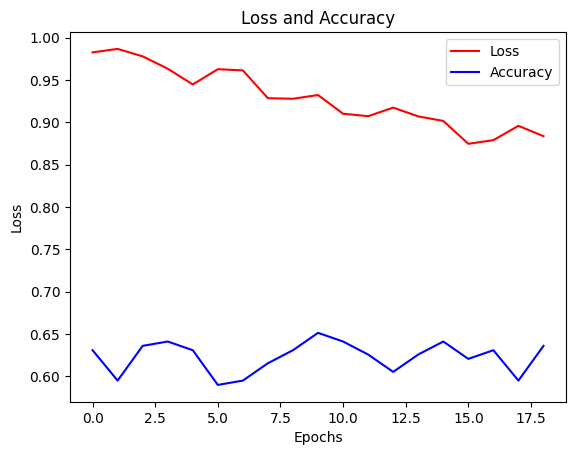

In [63]:
# matplotlib 이용하여 그래프 그리기
# 1. plot 그리기 : 입력  history.history['loss'], 'r'
# 2. plot 그리기 : 입력  history.history['accuracy'], 'b'
# 3. title : 'Loss and Accuracy'
# 4. xlabel : "Epochs"
# 5. ylabel : "Loss"
# 6. legend : ["Loss", "Accuracy"]
# 7. plt.show()


plt.plot(history.history['loss'], 'r')
plt.plot(history.history['accuracy'], 'b')
plt.title('Loss and Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Loss", "Accuracy"])
plt.show()

<br>
<br>
<br>

# **[실습] 딥러닝 모델링하기**

**아래 가이드에 따라 tips 데이터프레임을 활용하여 딥러닝 모델을 만드세요.**

- **회귀 DNN 모델 만들기**
  - 대상 데이터 : tips 데이터프레임
  - X, y 데이터 만들기
    - y 레이블 : total_bill
    - x 퓨쳐 : total_bill 제외한 나머지
  - train_test_split 함수를 활용해서 학습 데이터셋과 테스트 데이터셋을 만드세요.
    - 학습데이터셋 : 테스트데이터셋 = 8 : 2
    - random_state : 41  
  - DNN 모델을 만드세요.
    - 첫번째 히든 레이어 : 유닛 6
    - 두번째 히든 레이어 : 유닛 4
    - 아웃풋레이어 : 유닛 1, activation=None
  - DNN 모델 컴파일 및 조기종료,  최적 성능 모델 저장 그리고 학습하세요.
    - 모델 compile : loss='mse', optimizer='adam', metrics=['mse', 'mae']
    - EarlyStopping : patience=3
    - ModelCheckpoint
    - 모델 학습 fit
  - 만든 DNN 모델을 활용해서 아래 시뮬레이션 데이터에 대한 예측하세요.
    - 시뮬레이션 데이터 :  [3.23, 1.  , 0.  , 2.  , 1.  , 2.  ]

- **분류 DNN 모델 만들기**
  - 대상 데이터 : tips 데이터프레임
  - X, y 데이터 만들기
    - y 레이블 : smoker
    - x 퓨쳐 : smoker 제외한 나머지
  - train_test_split 함수를 활용해서 학습 데이터셋과 테스트 데이터셋을 만드세요.
    - 학습데이터셋 : 테스트데이터셋 = 8 : 2
    - random_state : 41  
  - DNN 모델을 만드세요.
    - 첫번째 히든 레이어 : 유닛 6
    - 두번째 히든 레이어 : 유닛 4
    - 아웃풋레이어 : 유닛 1, , activation='sigmoid'
  - DNN 모델 컴파일 및 조기종료,  최적 성능 모델 저장 그리고 학습하세요.
    - 모델 compile : loss='mse', optimizer='adam', metrics=['mse', 'mae']
    - EarlyStopping : patience=3
    - ModelCheckpoint
    - 모델 학습 fit
  - 만든 DNN 모델을 활용해서 아래 시뮬레이션 데이터에 대한 예측하세요.
    - 시뮬레이션 데이터 :  [23.33,  5.65,  1.  ,  2.  ,  1.  ,  2.  ]

**회귀 DNN 모델**

In [64]:
# X, y 나누기
X = tips.drop('total_bill', axis=1)
y = tips[ 'total_bill' ]

In [66]:
# 학습 데이터셋과 테스트 데이터셋 나누기
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=41 )
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 6), (49, 6), (195,), (49,))

In [68]:
# DNN 모델 생성 및 학습
# 첫번째 히든 레이어 : 유닛 6
# 두번째 히든 레이어 : 유닛 4
# 아웃풋레이어 : 유닛 1

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Sequential 모델 생성
model = Sequential()
model.add(  Dense( 6, activation='relu', input_shape=(6,)  )  )
model.add(  Dense( 4, activation='relu',  )  )
model.add(  Dense( 1, activation=None  )  )

# 컴파일
model.compile(  loss='mse', optimizer='adam', metrics=['mse', 'mae']  )

# EarlyStopping : 매 epoch 마다 'val_loss' 측정해서  3번 동안 더 이상 성능이 나아지지 않으면 조기 종료
es = EarlyStopping( monitor='val_loss' , patience=3 , verbose=1 )

# ModelCheckpoint : 매 epoch 마다 'val_loss' 측정해서  이전보다 성능이 더 좋아지면 모델을 저장
mc = ModelCheckpoint( 'best_model.keras', monitor='val_loss', save_best_only=True, verbose=1  )

# 모델 학습
history = model.fit(  X_train , y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test) , callbacks=[es, mc] )

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 505.1605 - mae: 20.4041 - mse: 505.1605
Epoch 1: val_loss improved from None to 410.29626, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 479.5517 - mae: 19.9374 - mse: 479.5517 - val_loss: 410.2963 - val_mae: 18.7602 - val_mse: 410.2963
Epoch 2/50
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 453.6351 - mae: 18.9300 - mse: 453.6351
Epoch 2: val_loss improved from 410.29626 to 388.77380, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 453.0260 - mae: 19.3063 - mse: 453.0260 - val_loss: 388.7738 - val_mae: 18.2046 - val_mse: 388.7738
Epoch 3/50
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 499.2541 - mae: 20.1994 - mse: 499.2541
Epoch 3: val_loss improved from 388.77380 to 368.30829, saving model to best_model.keras

Epoch 3: finished saving model to best_mod

In [74]:
# DNN 모델을 활용해서 시뮬레이션 데이터 예측하기

simul = [3.23, 1. , 0. , 2. , 1. , 2. ]
input_data = np.array([simul], dtype='float32')
model.predict(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([[0.8085476]], dtype=float32)

<br>

**분류 DNN 모델**

In [75]:
# X, y 나누기
X = tips.drop('smoker', axis=1)
y = tips[ 'smoker' ]

In [76]:
# 학습 데이터셋과 테스트 데이터셋 나누기
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=41 )
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((195, 6), (49, 6), (195,), (49,))

In [78]:
# DNN 모델 생성 및 학습
# 첫번째 히든 레이어 : 유닛 6
# 두번째 히든 레이어 : 유닛 4
# 아웃풋레이어 : 유닛 1

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Sequential 모델 생성
model = Sequential()
model.add(  Dense( 6, activation='relu', input_shape=(6,)  )  )
model.add(  Dense( 4, activation='relu',  )  )
model.add(  Dense( 1, activation='sigmoid'  )  )

# 컴파일
model.compile(  loss='mse', optimizer='adam', metrics=['mse', 'mae']  )

# EarlyStopping : 매 epoch 마다 'val_loss' 측정해서  3번 동안 더 이상 성능이 나아지지 않으면 조기 종료
es = EarlyStopping( monitor='val_loss' , patience=3 , verbose=1 )

# ModelCheckpoint : 매 epoch 마다 'val_loss' 측정해서  이전보다 성능이 더 좋아지면 모델을 저장
mc = ModelCheckpoint( 'best_model.keras', monitor='val_loss', save_best_only=True, verbose=1  )

# ==================== dtype 변환 ====================
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')
y_train = y_train.astype('float32')
y_test  = y_test.astype('float32')
# ============================================================

# 모델 학습
history = model.fit(  X_train , y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test) , callbacks=[es, mc] )

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5790 - mae: 0.5866 - mse: 0.5790
Epoch 1: val_loss improved from None to 0.67829, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.5880 - mae: 0.5957 - mse: 0.5880 - val_loss: 0.6783 - val_mae: 0.7024 - val_mse: 0.6783
Epoch 2/50
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5060 - mae: 0.5549 - mse: 0.5060
Epoch 2: val_loss improved from 0.67829 to 0.31238, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4848 - mae: 0.5777 - mse: 0.4848 - val_loss: 0.3124 - val_mae: 0.4806 - val_mse: 0.3124
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2936 - mae: 0.4588 - mse: 0.2936
Epoch 3: val_loss improved from 0.31238 to 0.23747, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/

In [80]:
# DNN 모델을 활용해서 시뮬레이션 데이터 예측하기

simul = [23.33,  5.65,  1.  ,  2.  ,  1.  ,  2.  ]
input_data = np.array([simul], dtype='float32')
model.predict(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[0.9346043]], dtype=float32)

---